In [43]:
import numpy as np
import pandas as pd

In [44]:
import numpy as np

def one_hot_encode(y, num_classes=None):
    y = np.array(y)
    if num_classes is None:
        num_classes = np.max(y) + 1
    
    one_hot = np.zeros((len(y), num_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot

In [45]:
class SoftmaxRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.W = None
        self.b = None

    def softmax(self, z):
        exp_z = np.exp(z)
        sum_exp_z = np.sum(exp_z, axis=1, keepdims=True)
        return exp_z / sum_exp_z

    def cross_entropy(self, y, y_pred):
        loss = -np.sum(y * np.log(y_pred)) / y.shape[0]
        return loss

    def predict(self, X):
        z = np.dot(X, self.W) + self.b
        y_pred = self.softmax(z)
        return np.argmax(y_pred, axis=1)
    
    def predict_classes(self, X):
        z = self.predict(X)
        return np.argmax(z, axis=1)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        y_onehot = one_hot_encode(y, n_classes)

        self.W = np.random.rand(n_features, n_classes)
        self.b = np.random.rand(1, n_classes)

        for epoch in range(self.epochs):
            z = np.dot(X, self.W) + self.b
            y_pred = self.softmax(z)

            dw = np.dot(X.T, (y_pred - y_onehot)) / n_samples
            db = np.sum(y_pred - y_onehot, axis=0, keepdims=True) / n_samples

            self.W -= self.lr * dw
            self.b -= self.lr * db

            if epoch % 100 == 0:
                loss = self.cross_entropy(y_onehot, y_pred)
                print(f'Epoch {epoch}, Loss: {loss}')

In [46]:
def evaluate_model(y_true, y_pred, num_classes=10):
    accuracy = np.mean(y_true == y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%\n")
    
    precisions = []
    recalls = []
    f1_scores = []

    for cls in range(num_classes):
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

    macro_precision = np.mean(precisions)
    macro_recall = np.mean(recalls)
    macro_f1 = np.mean(f1_scores)

    print("Macro Averages:")
    print(f"  Precision: {macro_precision:.2f}")
    print(f"  Recall:    {macro_recall:.2f}")
    print(f"  F1 Score:  {macro_f1:.2f}")


In [47]:
from tensorflow.keras.datasets import mnist

In [48]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


[0 1 2 3 4 5 6 7 8 9]


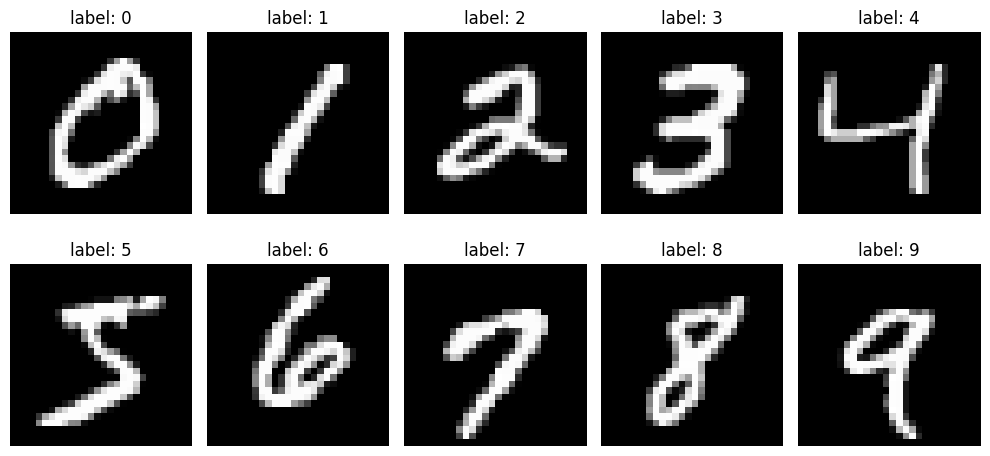

In [49]:
import matplotlib.pyplot as plt

unique_labels = np.unique(y_train)
print(unique_labels)

plt.figure(figsize=(10, 5))
for label in unique_labels:
    index = np.where(y_train == label)[0][0]
    plt.subplot(2, 5, label + 1)
    plt.imshow(X_train[index], cmap='gray')
    plt.title(f"label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [50]:
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0
print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape : (60000, 784)
X_test shape : (10000, 784)


In [51]:
model = SoftmaxRegression(learning_rate=0.1, epochs=1000)
model.fit(X_train, y_train)

Epoch 0, Loss: 3.945751597811271
Epoch 100, Loss: 0.8588044477288751
Epoch 200, Loss: 0.6392026845017171
Epoch 300, Loss: 0.5527503886804732
Epoch 400, Loss: 0.5041218830157826
Epoch 500, Loss: 0.4721087354018732
Epoch 600, Loss: 0.4490736564178487
Epoch 700, Loss: 0.43151559843271686
Epoch 800, Loss: 0.41757732587803076
Epoch 900, Loss: 0.40617241007432536


In [52]:
y_pred = model.predict(X_test)
evaluate_model(y_pred=y_pred, y_true=y_test)

Accuracy: 88.45%

Macro Averages:
  Precision: 0.88
  Recall:    0.88
  F1 Score:  0.88


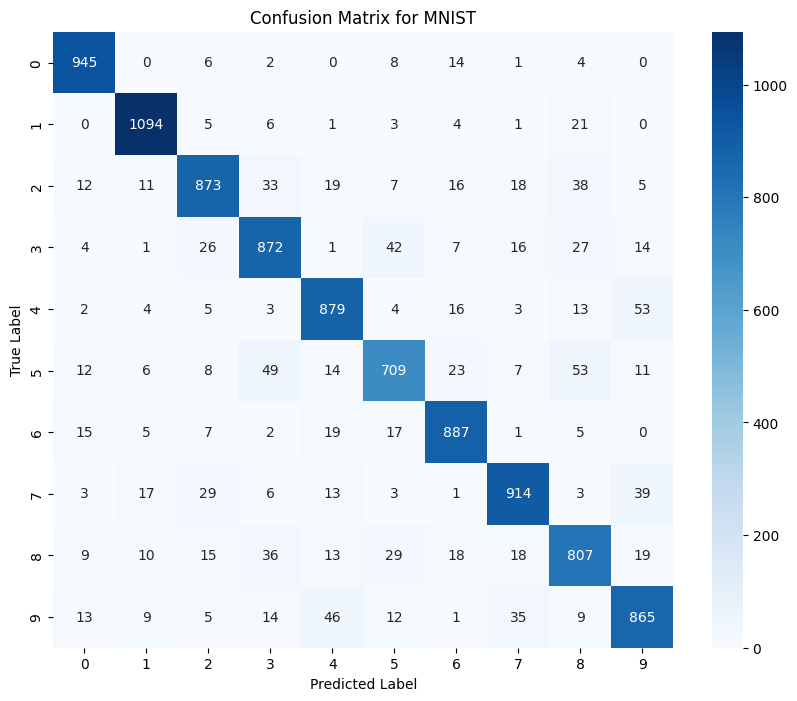

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[str(i) for i in range(10)],
                yticklabels=[str(i) for i in range(10)])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for MNIST')
    plt.show()
y_pred = model.predict(X_test)
plot_confusion_matrix(y_test, y_pred, unique_labels)